My dataset: https://www.kaggle.com/code/ahmedmahmoud16/california-housing-prices/input 

<h3>Can we predict the median house value in California districts based on features such as median income, total rooms, total bedrooms, population, households, and proximity to the ocean using a linear regression model?</h3>

<h1>Part 1: Training Your Algorithm</h1>

<p>Training Your Algorithm</p>
For this project you can use your trained algorithm from Assignment 1, or you can find a new algorithm
to train. Your dataset must have at least 5 columns for X used in your model. It must also have at least
200 records after modifications.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv("housing.csv")

df.head(300)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
295,-122.17,37.77,31.0,2424.0,533.0,1360.0,452.0,1.8710,90700.0,NEAR BAY
296,-122.17,37.76,41.0,1594.0,367.0,1074.0,355.0,1.9356,90600.0,NEAR BAY
297,-122.17,37.76,47.0,2118.0,413.0,965.0,382.0,2.1842,107900.0,NEAR BAY
298,-122.18,37.76,37.0,1575.0,358.0,933.0,320.0,2.2917,107000.0,NEAR BAY


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [46]:
df["ocean_proximity"].unique()


array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [47]:
df.replace('NEAR BAY', 0, inplace=True)
df.replace('<1H OCEAN', 1, inplace=True)
df.replace('INLAND', 2, inplace=True)
df.replace('NEAR OCEAN', 3, inplace=True)
df.replace('ISLAND', 4, inplace=True)


C:\Users\hp\AppData\Local\Temp\ipykernel_25016\785464869.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('ISLAND', 4, inplace=True)


In [48]:
df.dropna(axis=0, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 1.7 MB


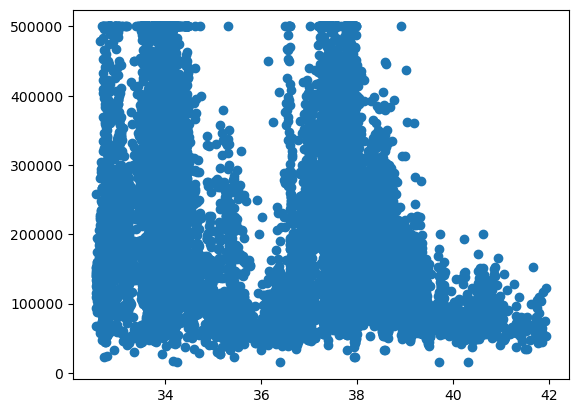

In [49]:
x1 = df['latitude']
y= df['median_house_value']
plt.scatter(x1, y, lw=1)

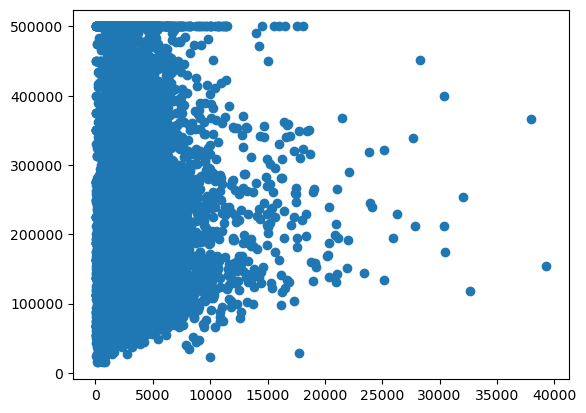

In [50]:
x2 = df['total_rooms']
y= df['median_house_value']
plt.scatter(x2, y, lw=1)

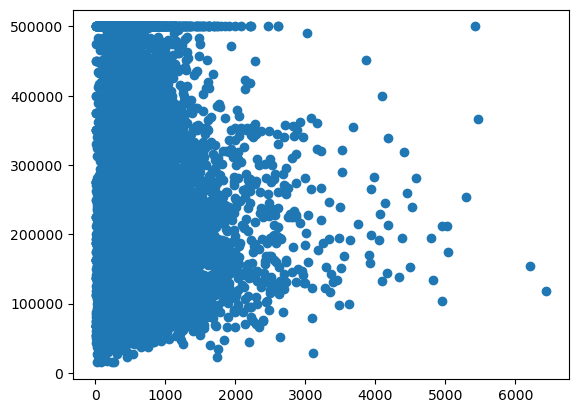

In [51]:
x3 = df['total_bedrooms']
y= df['median_house_value']
plt.scatter(x3, y, lw=1)

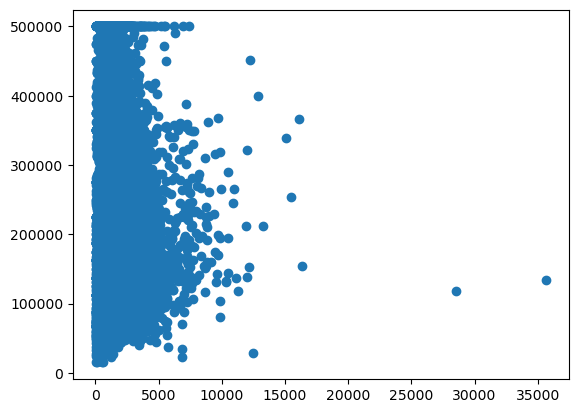

In [52]:
x4 = df['population']
y= df['median_house_value']
plt.scatter(x4, y, lw=1)

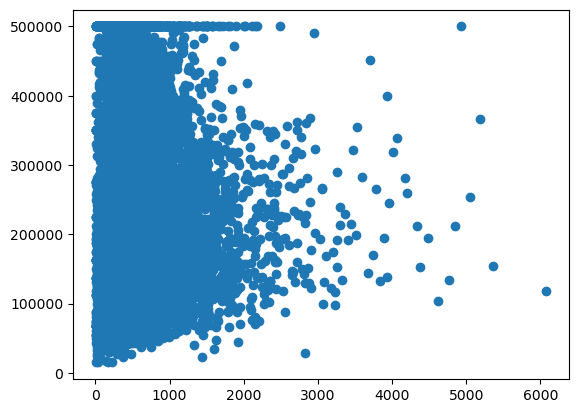

In [53]:
x5 = df['households']
y= df['median_house_value']
plt.scatter(x5, y, lw=1)

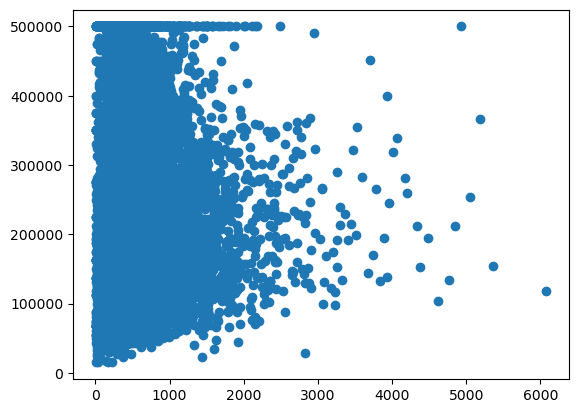

In [54]:
x6 = df['households']
y= df['median_house_value']
plt.scatter(x6, y, lw=1)

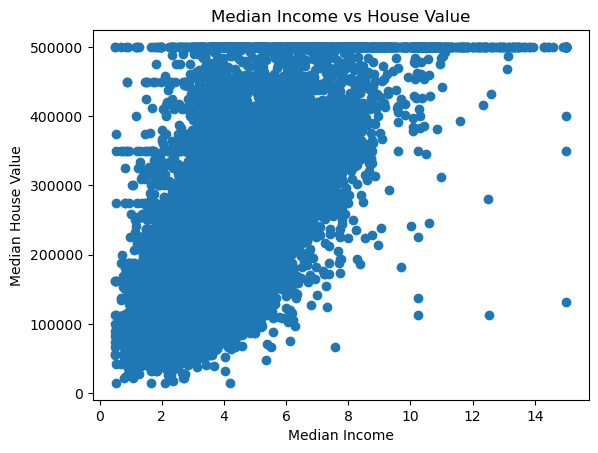

In [55]:
x7 = df['median_income']
y= df['median_house_value']
plt.scatter(x7, y, lw=1)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Median Income vs House Value')
plt.show()

In [56]:
# features = ['median_income', 'total_rooms', 'total_bedrooms', 'population', 'households', 'ocean_proximity', 'housing_median_age', 'longitude', 'latitude']
# X = df[features]
# y = df['median_house_value'].values

In [57]:
from sklearn.model_selection import train_test_split

X, y = df.drop('median_house_value', axis=1), df['median_house_value'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [ ]:
# #Predicting the results
# predictions = model.predict(X_test)
# model.score(X_test, y_test)



4915187970.742721 0.6405760152174986


<h1>Part 2 to Part 3</h1>

In [60]:
from flask import Flask, request, jsonify
app = Flask(__name__)
# sample_record = X.iloc[0].to_dict()




In [61]:
#example
df.drop('median_house_value', axis=1).iloc[0]

longitude            -122.2300
latitude               37.8800
housing_median_age     41.0000
total_rooms           880.0000
total_bedrooms        129.0000
population            322.0000
households            126.0000
median_income           8.3252
ocean_proximity         0.0000
Name: 0, dtype: float64

In [62]:
#example
sample_json = X.iloc[0].to_json(orient="index")
sample_json

'{"longitude":-122.23,"latitude":37.88,"housing_median_age":41.0,"total_rooms":880.0,"total_bedrooms":129.0,"population":322.0,"households":126.0,"median_income":8.3252,"ocean_proximity":0.0}'

In [63]:
app = Flask(__name__)

In [64]:
# -----------------------
# PART 3 — SAMPLE
# -----------------------
@app.get("/housing/sample")
def sample():
    return X.iloc[0].to_json(orient="index")

In [65]:
# -----------------------
# PART 4 — EXPLAIN
# -----------------------
@app.get("/housing/explain")
def explain():
    text = "This model predicts housing price using these fields:\n\n"

    for col in X.columns:
        text += f"- {col}: numeric value\n"

    text += "\nThe output is 'median_house_value', a numeric prediction."
    return text

In [66]:

# -----------------------
# PART 5 — EVALUATE
# -----------------------
@app.post("/housing/evaluate")
def evaluate():
    if request.is_json:
        user_data = request.get_json()

        df_in = pd.DataFrame([user_data])

        result = model.predict(df_in)
        return '{}'.format(result[0])
    
    return {"error": "Request must be JSON"}

In [67]:
if __name__ == "__main__":
    app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
